# Лабораторная работа 5
## Решение смешанной задачи для уравнения теплопроводности

**Вариант 6:**
$$\frac{\partial U}{\partial t} = t\frac{\partial^2 U}{\partial x^2} + x\frac{\partial U}{\partial x} + xt$$

$$U(x,0)=x^2, \quad U(0,t)=t, \quad U(1,t)=1+t, \quad T=1$$

In [31]:
import numpy as np
import matplotlib.pyplot as plt

T = 1.0  # конечное время

## Метод прогонки (алгоритм Томаса)

Решает трёхдиагональную систему: $a_i u_{i-1} + b_i u_i + c_i u_{i+1} = d_i$

In [32]:
def thomas(a, b, c, d):
    """
    Метод прогонки (алгоритм Томаса) для трёхдиагональной системы.
    a[i]*x[i-1] + b[i]*x[i] + c[i]*x[i+1] = d[i]
    a[0] и c[-1] не используются.
    """
    n = len(d)
    c_ = np.zeros(n)
    d_ = np.zeros(n)
    x  = np.zeros(n)

    # Прямой ход
    c_[0] = c[0] / b[0]
    d_[0] = d[0] / b[0]
    for i in range(1, n):
        denom = b[i] - a[i] * c_[i-1]
        c_[i] = c[i] / denom
        d_[i] = (d[i] - a[i] * d_[i-1]) / denom

    # Обратный ход
    x[-1] = d_[-1]
    for i in range(n - 2, -1, -1):
        x[i] = d_[i] - c_[i] * x[i+1]

    return x

## Задание 1: Явная двухслойная схема


In [33]:
def solve_explicit(Nx, T=1.0):
    """
    Явная двухслойная схема для уравнения теплопроводности.
    Шаг по времени выбирается из условия устойчивости: tau <= 0.4 * h^2 / T
    """
    h = 1.0 / (Nx - 1)
    x = np.linspace(0.0, 1.0, Nx)

    # Условие устойчивости: r = tau*T/h^2 <= 0.5
    # Используем коэффициент 0.4 для запаса
    tau = 0.4 * h**2 / T
    Nt = max(int(np.ceil(T / tau)), 1)
    tau = T / Nt

    U = x**2  # начальное условие
    t_cur = 0.0

    for _ in range(Nt):
        d2u = (U[2:] - 2*U[1:-1] + U[:-2]) / h**2   # d²U/dx²
        du  = (U[2:] - U[:-2]) / (2*h)               # dU/dx (центральная разность)

        U_new = np.empty_like(U)
        U_new[1:-1] = U[1:-1] + tau * (
            t_cur * d2u + x[1:-1] * du + x[1:-1] * t_cur
        )

        t_cur += tau
        # Граничные условия
        U_new[0]  = t_cur
        U_new[-1] = 1.0 + t_cur
        U = U_new

    return x, U, tau, Nt

=== Явная схема ===
   Nx        h          tau       Nt   r=tau*T/h²
   11   0.1000     4.00e-03      250       0.4000
   51   0.0200     1.60e-04     6250       0.4000
  101   0.0100     4.00e-05    25000       0.4000


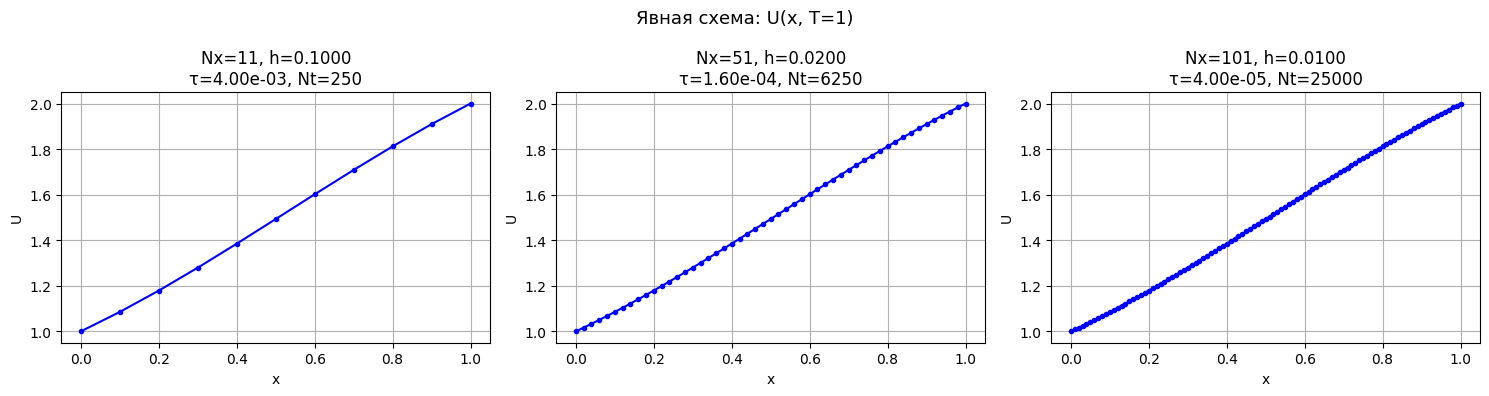

In [ ]:
grids = [11, 51, 101]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Явная схема: U(x, T=1)", fontsize=13)

results_exp = {}
print("Явная схема")
print(f"{'Nx':>5} {'h':>8} {'tau':>12} {'Nt':>8} {'r=tau*T/h²':>12}")

for ax, Nx in zip(axes, grids):
    x, U, tau, Nt = solve_explicit(Nx, T)
    results_exp[Nx] = (x, U)
    h = 1.0 / (Nx - 1)
    r = tau * T / h**2
    print(f"{Nx:>5} {h:>8.4f} {tau:>12.2e} {Nt:>8} {r:>12.4f}")

    ax.plot(x, U, 'b-o', markersize=3, label='Явная')
    ax.set_title(f"Nx={Nx}, h={h:.4f}\nτ={tau:.2e}, Nt={Nt}")
    ax.set_xlabel("x")
    ax.set_ylabel("U")
    ax.grid(True)

plt.tight_layout()
plt.show()

### Исследование устойчивости явной схемы


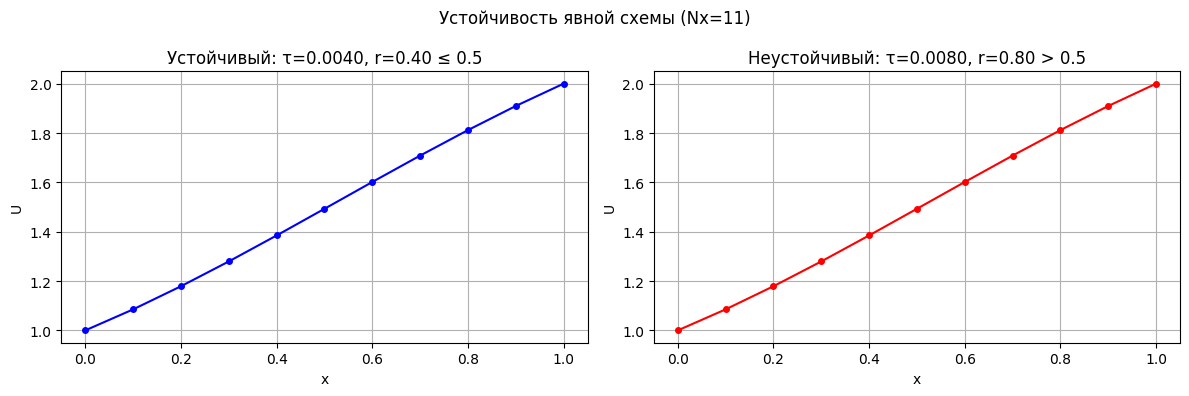

In [35]:
# Демонстрация неустойчивости при нарушении условия CFL
Nx_demo = 11
h_demo  = 1.0 / (Nx_demo - 1)
x_demo  = np.linspace(0.0, 1.0, Nx_demo)

# Явно нарушаем условие устойчивости: r > 0.5
tau_unstable = 0.8 * h_demo**2 / T   # r = 0.8 > 0.5 → неустойчиво
tau_stable   = 0.4 * h_demo**2 / T   # r = 0.4 < 0.5 → устойчиво

def run_explicit_tau(Nx, tau, T=1.0, max_steps=None):
    h = 1.0 / (Nx - 1)
    x = np.linspace(0.0, 1.0, Nx)
    Nt = int(np.ceil(T / tau))
    if max_steps:
        Nt = min(Nt, max_steps)
    U = x**2
    t_cur = 0.0
    for _ in range(Nt):
        d2u = (U[2:] - 2*U[1:-1] + U[:-2]) / h**2
        du  = (U[2:] - U[:-2]) / (2*h)
        U_new = np.empty_like(U)
        U_new[1:-1] = U[1:-1] + tau * (t_cur * d2u + x[1:-1] * du + x[1:-1] * t_cur)
        t_cur += tau
        U_new[0]  = t_cur
        U_new[-1] = 1.0 + t_cur
        U = U_new
        if np.any(np.abs(U) > 1e10):  # остановка при расходимости
            print(f"  [!] Расходимость на шаге {_+1}")
            break
    return x, U

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Устойчивость явной схемы (Nx=11)", fontsize=12)

x_s, U_s = run_explicit_tau(Nx_demo, tau_stable, T)
r_s = tau_stable * T / h_demo**2
axes[0].plot(x_s, U_s, 'b-o', markersize=4)
axes[0].set_title(f"Устойчивый: τ={tau_stable:.4f}, r={r_s:.2f} ≤ 0.5")
axes[0].set_xlabel("x"); axes[0].set_ylabel("U"); axes[0].grid(True)

x_u, U_u = run_explicit_tau(Nx_demo, tau_unstable, T, max_steps=500)
r_u = tau_unstable * T / h_demo**2
U_plot = np.clip(U_u, -100, 100)
axes[1].plot(x_u, U_plot, 'r-o', markersize=4)
axes[1].set_title(f"Неустойчивый: τ={tau_unstable:.4f}, r={r_u:.2f} > 0.5")
axes[1].set_xlabel("x"); axes[1].set_ylabel("U"); axes[1].grid(True)

plt.tight_layout()
plt.show()

## Задание 2: Неявная двухслойная схема (метод прогонки)



In [44]:
def solve_implicit(Nx, Nt=1000, T=1.0):
    h   = 1.0 / (Nx - 1)
    tau = T / Nt
    x   = np.linspace(0.0, 1.0, Nx)

    U     = x**2  # начальное условие
    t_cur = 0.0

    for _ in range(Nt):
        t_new = t_cur + tau
        xi    = x[1:-1]    # внутренние узлы
        m     = Nx - 2     # количество внутренних узлов

        a = -t_new / h**2 + xi / (2*h)
        b = np.full(m, 1/tau + 2*t_new / h**2)
        c = -t_new / h**2 - xi / (2*h)
        d =  U[1:-1] / tau + xi * t_new

        # Учёт граничных условий
        d[0]  -= a[0]  * t_new          # U[0]^{n+1} = t_new
        d[-1] -= c[-1] * (1.0 + t_new)  # U[N]^{n+1} = 1 + t_new

        U_int = thomas(a, b, c, d)

        U_new       = np.empty(Nx)
        U_new[0]    = t_new
        U_new[1:-1] = U_int
        U_new[-1]   = 1.0 + t_new

        U     = U_new
        t_cur = t_new

    return x, U

Неявная схема
   Nx        h       Nt        tau
   11   0.1000     1000     0.0010
   51   0.0200     1000     0.0010
  101   0.0100     1000     0.0010


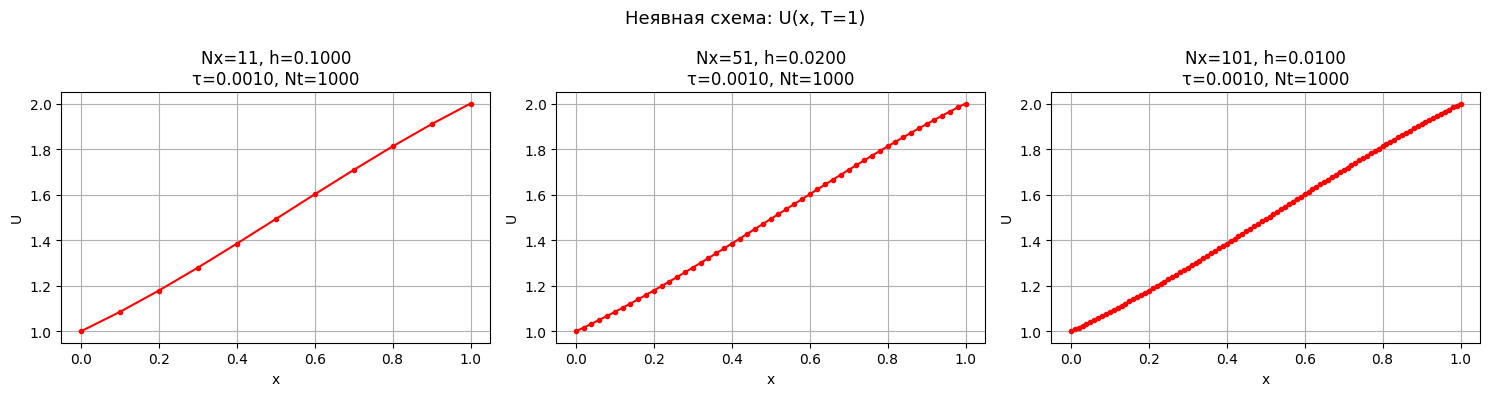

In [45]:
Nt_implicit = 1000

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Неявная схема: U(x, T=1)", fontsize=13)

results_imp = {}
print("Неявная схема")
print(f"{'Nx':>5} {'h':>8} {'Nt':>8} {'tau':>10}")

for ax, Nx in zip(axes, grids):
    x, U = solve_implicit(Nx, Nt_implicit, T)
    results_imp[Nx] = (x, U)
    h   = 1.0 / (Nx - 1)
    tau = T / Nt_implicit
    print(f"{Nx:>5} {h:>8.4f} {Nt_implicit:>8} {tau:>10.4f}")

    ax.plot(x, U, 'r-o', markersize=3, label='Неявная')
    ax.set_title(f"Nx={Nx}, h={h:.4f}\nτ={tau:.4f}, Nt={Nt_implicit}")
    ax.set_xlabel("x")
    ax.set_ylabel("U")
    ax.grid(True)

plt.tight_layout()
plt.show()

## Сравнение явной и неявной схем

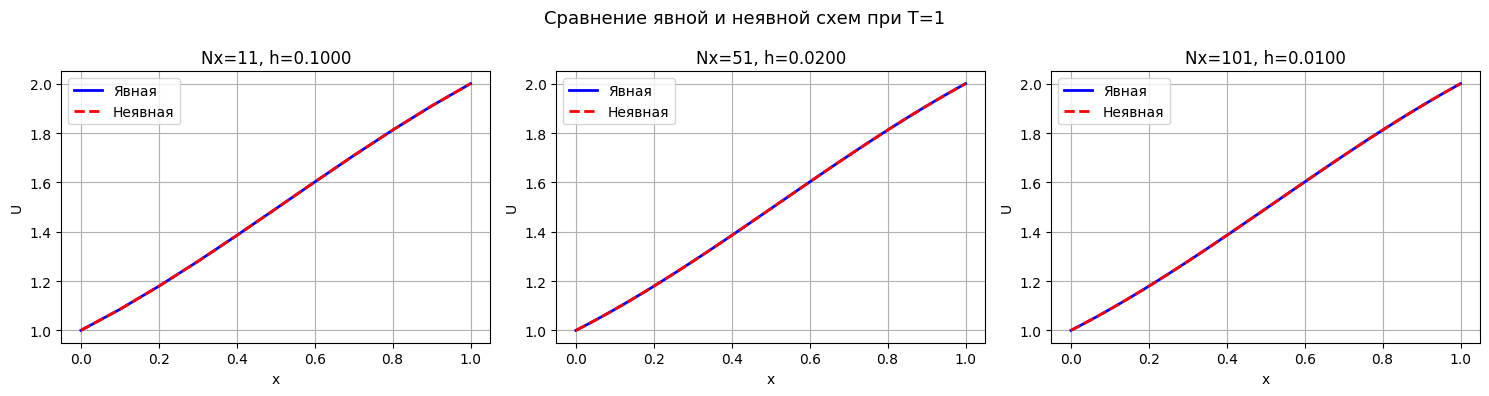

Максимальное отклонение |U_явная - U_неявная| (интерполяция на одну сетку):
  Nx=11: max|err| = 1.309484e-04
  Nx=51: max|err| = 2.973163e-05
  Nx=101: max|err| = 2.663501e-05


In [38]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Сравнение явной и неявной схем при T=1", fontsize=13)

for ax, Nx in zip(axes, grids):
    h = 1.0 / (Nx - 1)
    x_e, U_e = results_exp[Nx]
    x_i, U_i = results_imp[Nx]

    ax.plot(x_e, U_e, 'b-',  linewidth=2, label='Явная')
    ax.plot(x_i, U_i, 'r--', linewidth=2, label='Неявная')
    ax.set_title(f"Nx={Nx}, h={h:.4f}")
    ax.set_xlabel("x")
    ax.set_ylabel("U")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

# Максимальное отклонение между схемами
print("Максимальное отклонение |U_явная - U_неявная| (интерполяция на одну сетку):")
for Nx in grids:
    x_e, U_e = results_exp[Nx]
    x_i, U_i = results_imp[Nx]
    # Сетки одинаковые, сравниваем напрямую
    diff = np.max(np.abs(U_e - U_i))
    print(f"  Nx={Nx}: max|err| = {diff:.6e}")

## Исследование аппроксимации (сходимость по пространству)

In [39]:
# Оценка порядка сходимости: сравниваем решения на разных сетках
# Используем решение на сетке 101 как «эталон» (интерполируем более грубые)

Nx_ref = 101
x_ref_e, U_ref_e = results_exp[Nx_ref]
x_ref_i, U_ref_i = results_imp[Nx_ref]

print("Оценка порядка аппроксимации")
print("Явная схема (относительно Nx=101):")
errs_exp = []
hs = []
for Nx in [11, 51]:
    x_e, U_e = results_exp[Nx]
    # Интерполируем решение на мелкую сетку
    U_interp = np.interp(x_ref_e, x_e, U_e)
    err = np.max(np.abs(U_interp - U_ref_e))
    h = 1.0 / (Nx - 1)
    errs_exp.append(err)
    hs.append(h)
    print(f"  Nx={Nx}, h={h:.4f}: max|err|={err:.4e}")

if len(errs_exp) >= 2 and errs_exp[1] > 0 and errs_exp[0] > 0:
    order_exp = np.log(errs_exp[0]/errs_exp[1]) / np.log(hs[0]/hs[1])
    print(f"  Порядок сходимости по h: ~{order_exp:.2f}")

print()
print("Неявная схема (относительно Nx=101):")
errs_imp = []
for Nx in [11, 51]:
    x_i, U_i = results_imp[Nx]
    U_interp = np.interp(x_ref_i, x_i, U_i)
    err = np.max(np.abs(U_interp - U_ref_i))
    h = 1.0 / (Nx - 1)
    errs_imp.append(err)
    print(f"  Nx={Nx}, h={h:.4f}: max|err|={err:.4e}")

if len(errs_imp) >= 2 and errs_imp[1] > 0 and errs_imp[0] > 0:
    order_imp = np.log(errs_imp[0]/errs_imp[1]) / np.log(hs[0]/hs[1])
    print(f"  Порядок сходимости по h: ~{order_imp:.2f}")

Оценка порядка аппроксимации
Явная схема (относительно Nx=101):
  Nx=11, h=0.1000: max|err|=1.1102e-03
  Nx=51, h=0.0200: max|err|=4.8984e-05
  Порядок сходимости по h: ~1.94

Неявная схема (относительно Nx=101):
  Nx=11, h=0.1000: max|err|=1.0925e-03
  Nx=51, h=0.0200: max|err|=4.8878e-05
  Порядок сходимости по h: ~1.93


## График решения в динамике (эволюция по времени, неявная схема, Nx=51)

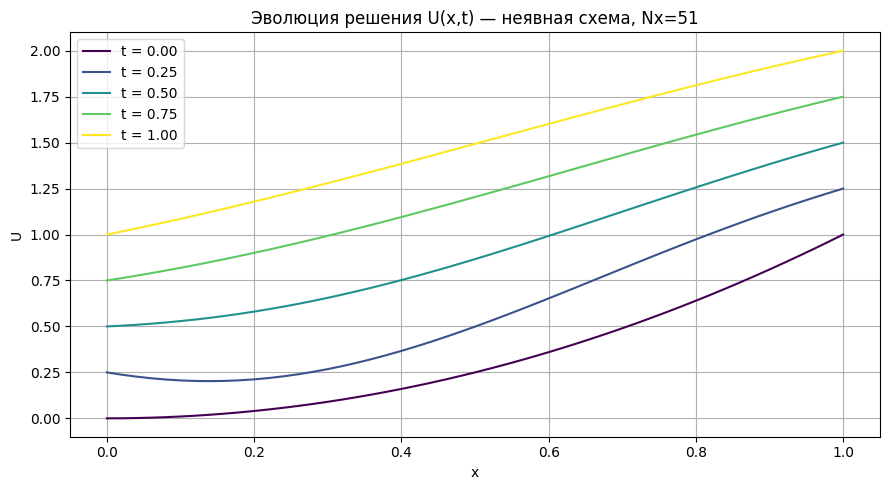

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def solve_implicit_snapshots(Nx, Nt=1000, T=1.0, snap_times=None):
    """Неявная схема с сохранением снимков в заданные моменты времени."""
    h   = 1.0 / (Nx - 1)
    tau = T / Nt
    x   = np.linspace(0.0, 1.0, Nx)
    if snap_times is None:
        snap_times = [0.0, 0.25, 0.5, 0.75, 1.0]

    snapshots = {}
    U     = x**2
    t_cur = 0.0
    # Сохраняем начальное состояние
    if 0.0 in snap_times:
        snapshots[0.0] = U.copy()

    m = Nx - 2  # Количество внутренних узлов

    for n in range(Nt):
        t_new = t_cur + tau
        xi    = x[1:-1]    # Внутренние узлы (массив длины m)

        # Коэффициенты трехдиагональной матрицы
        a = -t_new / h**2 + xi / (2*h)
        
        b = np.full(m, 1/tau + 2*t_new / h**2)
        
        c = -t_new / h**2 - xi / (2*h)
        d =  U[1:-1] / tau + xi * t_new

        # Учёт граничных условий
        d[0]  -= a[0]  * t_new          # U[0]^{n+1} = t_new
        d[-1] -= c[-1] * (1.0 + t_new)  # U[N]^{n+1} = 1 + t_new

        U_int = thomas(a, b, c, d)

        U_new       = np.empty(Nx)
        U_new[0]    = t_new
        U_new[1:-1] = U_int
        U_new[-1]   = 1.0 + t_new
        
        U     = U_new
        t_cur = t_new

        # Проверка, попали ли в нужный момент времени для снимка
        for ts in snap_times:
            if ts not in snapshots and abs(t_cur - ts) < tau / 2:
                snapshots[ts] = U.copy()

    return x, snapshots

snap_times = [0.0, 0.25, 0.5, 0.75, 1.0]
x51, snaps = solve_implicit_snapshots(51, Nt=1000, T=1.0, snap_times=snap_times)

fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.viridis(np.linspace(0, 1, len(snap_times)))

# Сортируем ключи, чтобы рисовать линии по порядку времени
for t_s, col in zip(sorted(snaps.keys()), colors):
    ax.plot(x51, snaps[t_s], color=col, label=f't = {t_s:.2f}')

ax.set_title("Эволюция решения U(x,t) — неявная схема, Nx=51")
ax.set_xlabel("x")
ax.set_ylabel("U")
ax.legend(loc='upper left')
ax.grid(True)
plt.tight_layout()
plt.show()

## Итоговое сравнение и выводы

| Характеристика | Явная схема | Неявная схема |
|---|---|---|
| **Аппроксимация** | $O(\tau + h^2)$ | $O(\tau + h^2)$ |
| **Устойчивость** | Условная: $r = \tau t / h^2 \leq 0.5$ | Безусловная |
| **Шаг по времени** | $\tau \leq h^2 / (2T)$ — очень мал | Любой $\tau$ |
| **Кол-во операций/шаг** | $O(N)$ | $O(N)$ (прогонка) |
| **Всего шагов** | Очень много (для малого $h$) | Произвольно мало |
| **Разреженность** | — | Трёхдиагональная матрица |

**Вывод:** Неявная схема предпочтительна при малых $h$, так как не требует малого $\tau$. Для Nx=101 явная схема требует ~20000 шагов, неявная — 1000.

In [43]:
print("Итоговое сравнение числа шагов")
print(f"{'Nx':>5} {'h':>8} | {'Явная Nt':>12} {'tau_exp':>12} | {'Неявная Nt':>12} {'tau_imp':>10}")
for Nx in grids:
    h = 1.0 / (Nx - 1)
    tau_exp = 0.4 * h**2 / T
    Nt_exp  = max(int(np.ceil(T / tau_exp)), 1)
    tau_exp_actual = T / Nt_exp
    tau_imp = T / 1000
    print(f"{Nx:>5} {h:>8.4f} | {Nt_exp:>12} {tau_exp_actual:>12.2e} | {1000:>12} {tau_imp:>10.4f}")

Итоговое сравнение числа шагов
   Nx        h |     Явная Nt      tau_exp |   Неявная Nt    tau_imp
   11   0.1000 |          250     4.00e-03 |         1000     0.0010
   51   0.0200 |         6250     1.60e-04 |         1000     0.0010
  101   0.0100 |        25000     4.00e-05 |         1000     0.0010


In [ ]:

import numpy as np

def thomas(a, b, c, d):
    n = len(d)
    cp = np.zeros(n)
    dp = np.zeros(n)
    sol = np.zeros(n)
    cp[0] = c[0] / b[0]
    dp[0] = d[0] / b[0]
    for i in range(1, n):
        denom = b[i] - a[i] * cp[i-1]
        cp[i] = c[i] / denom
        dp[i] = (d[i] - a[i] * dp[i-1]) / denom
    sol[-1] = dp[-1]
    for i in range(n - 2, -1, -1):
        sol[i] = dp[i] - cp[i] * sol[i+1]
    return sol

def solve_implicit(Nx, Nt=1000, T=1.0):
    h   = 1.0 / (Nx - 1)
    tau = T / Nt
    x   = np.linspace(0.0, 1.0, Nx)
    m   = Nx - 2

    U     = x**2
    t_cur = 0.0

    for _ in range(Nt):
        t_new = t_cur + tau
        xi    = x[1:-1]

        a = -t_new / h**2 + xi / (2*h)
        b = np.full(m, 1.0/tau + 2.0*t_new / h**2)
        c = -t_new / h**2 - xi / (2*h)
        d =  U[1:-1] / tau + xi * t_new

        d[0]  -= a[0]  * t_new
        d[-1] -= c[-1] * (1.0 + t_new)

        U_int = thomas(a, b, c, d)

        U_new       = np.empty(Nx)
        U_new[0]    = t_new
        U_new[1:-1] = U_int
        U_new[-1]   = 1.0 + t_new

        U     = U_new
        t_cur = t_new

    return x, U

# Проверка
for Nx in [11, 51, 101]:
    x, U = solve_implicit(Nx, 1000, 1.0)
    print(f"Nx={Nx}: U(0,1)={U[0]:.4f} (exp 1.0), U(1,1)={U[-1]:.4f} (exp 2.0), U(0.5)={np.interp(0.5,x,U):.6f}")


Nx=11: U(0,1)=1.0000 (exp 1.0), U(1,1)=2.0000 (exp 2.0), U(0.5)=1.492682
Nx=51: U(0,1)=1.0000 (exp 1.0), U(1,1)=2.0000 (exp 2.0), U(0.5)=1.493009
Nx=101: U(0,1)=1.0000 (exp 1.0), U(1,1)=2.0000 (exp 2.0), U(0.5)=1.493019
